<a href="https://colab.research.google.com/github/CS171-Semester-Project/traffic-sign-detection/blob/main/traffic_sign_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

In [2]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

###**DATA PREPARATION**

In [3]:
# Download the dataset
!kaggle datasets download -d pkdarabi/cardetection

# Unzip the downloaded dataset
!unzip -q cardetection.zip -d cardetection_dataset

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/cardetection
License(s): Attribution 4.0 International (CC BY 4.0)
100% 99.8M/99.8M [00:00<00:00, 120MB/s] 



In [4]:
for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/train"):
    print(f"Train data path: {dirpath}")
    print(f"Train data directories length: {len(dirnames)}")
    print(f"Train data filenames length: {len(filenames)}")

print()

for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/test"):
    print(f"Test data path: {dirpath}")
    print(f"Test data directories length: {len(dirnames)}")
    print(f"Test data filenames length: {len(filenames)}")

print()

for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/valid"):
    print(f"Validation data path: {dirpath}")
    print(f"Validation data directories length: {len(dirnames)}")
    print(f"Validation data filenames length: {len(filenames)}")

Train data path: cardetection_dataset/car/train
Train data directories length: 2
Train data filenames length: 0
Train data path: cardetection_dataset/car/train/images
Train data directories length: 0
Train data filenames length: 3530
Train data path: cardetection_dataset/car/train/labels
Train data directories length: 0
Train data filenames length: 3530

Test data path: cardetection_dataset/car/test
Test data directories length: 2
Test data filenames length: 0
Test data path: cardetection_dataset/car/test/images
Test data directories length: 0
Test data filenames length: 638
Test data path: cardetection_dataset/car/test/labels
Test data directories length: 0
Test data filenames length: 638

Validation data path: cardetection_dataset/car/valid
Validation data directories length: 2
Validation data filenames length: 0
Validation data path: cardetection_dataset/car/valid/images
Validation data directories length: 0
Validation data filenames length: 801
Validation data path: cardetection_da

In [5]:
import yaml

yaml_path = "cardetection_dataset/car/data.yaml"

with open(yaml_path, "r") as f:
    data_info = yaml.safe_load(f)

In [6]:
# Getting all the class or label names
class_names = data_info.get('names', [])
print(f"Total Number of Classes: {len(class_names)}\n")

print("Class Names:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Total Number of Classes: 15

Class Names:
0: Green Light
1: Red Light
2: Speed Limit 10
3: Speed Limit 100
4: Speed Limit 110
5: Speed Limit 120
6: Speed Limit 20
7: Speed Limit 30
8: Speed Limit 40
9: Speed Limit 50
10: Speed Limit 60
11: Speed Limit 70
12: Speed Limit 80
13: Speed Limit 90
14: Stop


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import glob

In [8]:
train_images_dir = "cardetection_dataset/car/train/images"
train_labels_dir = "cardetection_dataset/car/train/labels"

if os.path.exists(train_images_dir) and os.path.exists(train_labels_dir):
    image_files = [f for f in os.listdir(train_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if image_files:
        random_image = random.choice(image_files)
        # Labels usually have the same base name with a .txt extension in YOLO format
        corresponding_label = os.path.splitext(random_image)[0] + '.txt'

        print(f"Image File: {random_image}")
        print(f"Label File: {corresponding_label}")

        # Verify if the label file actually exists
        if os.path.exists(os.path.join(train_labels_dir, corresponding_label)):
            print("Status: Corresponding label file exists!")
        else:
            print("Status: Corresponding label file is missing.")

Image File: road443_png.rf.dd859e723641bc6d953e99b6ff8393db.jpg
Label File: road443_png.rf.dd859e723641bc6d953e99b6ff8393db.txt
Status: Corresponding label file exists!


In [9]:
# Get all train images
view_train_img = glob.glob("cardetection_dataset/car/train/images/*.jpg")
if not view_train_img:
    view_train_img = glob.glob("cardetection_dataset/car/valid/images/*.jpg")

In [10]:
print(f"Train images length: {len(view_train_img)}")

Train images length: 3530


In [11]:
# Function to get labels for each image
def get_labels(img_path):
    label_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")
    found_classes = set()
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 1:
                    class_id = int(parts[0])
                    if "data_info" in globals() and "names" in data_info:
                        class_name = data_info["names"][class_id]
                    else:
                        class_name = f"Class {class_id}"
                    found_classes.add(class_name)
    if found_classes:
        return f"\nLabel: {", ".join(list(found_classes))}"

    return "\nLabel: None"

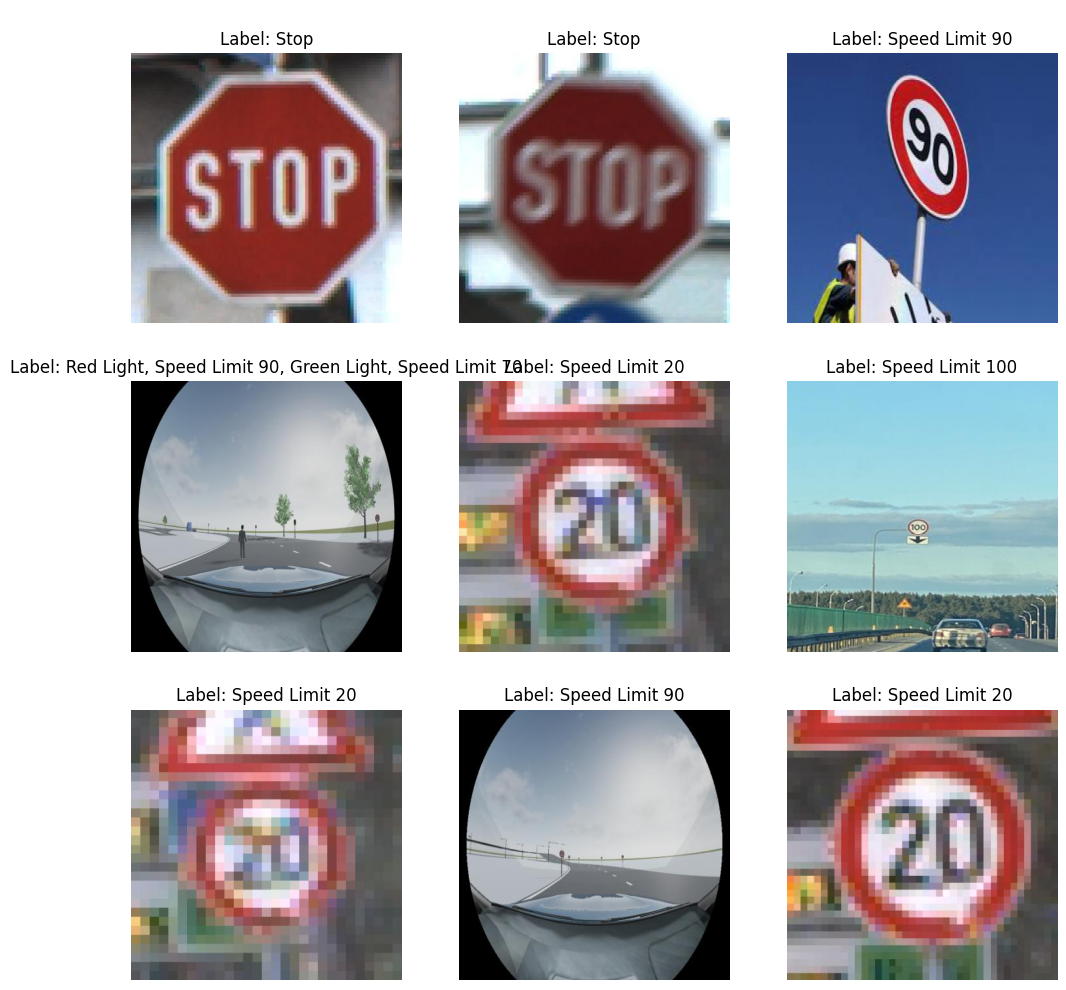

In [12]:
# Visualize multiple train images with labels
samples = random.sample(view_train_img, min(9, len(view_train_img)))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, img_path in enumerate(samples):
    ax =axes[i]
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")

    title = get_labels(img_path)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [13]:
train_labels_dir = "cardetection_dataset/car/train/labels"
if os.path.exists(train_labels_dir):
    label_files = os.listdir(train_labels_dir)
    print("Contents of 5 random label files:")

    num_samples = min(5, len(label_files))
    random_files = random.sample(label_files, num_samples)

    for file in random_files:
        file_path = os.path.join(train_labels_dir, file)
        print(f"--- {file} ---")
        with open(file_path, 'r') as f:
            print(f.read())
        print()
else:
    print("Directory not found.")

Contents of 5 random label files:
--- 00008_00007_00005_png.rf.acf326ae482f4fb728a570597b407975.txt ---
5 0.5600961538461539 0.5480769230769231 0.5372596153846154 0.5733173076923077

--- FisheyeCamera_1_00080_png.rf.cc26e0feb0e1c529f7c86e8ccc7218fc.txt ---
0 0.34375 0.3894230769230769 0.02283653846153846 0.015625

--- 000148_jpg.rf.b062ff7b34f4d4dba2b43ae4d02ef5d1.txt ---
9 0.6706730769230769 0.2824519230769231 0.359375 0.49759615384615385

--- 00000_00005_00023_png.rf.28d029f2b9b48ed768477a9713c16d9a.txt ---
6 0.5252403846153846 0.5024038461538461 0.7463942307692307 0.7752403846153846

--- road768_png.rf.5054cc21fb94903fb4e13ccabef3679f.txt ---
12 0.40625 0.5132211538461539 0.0733173076923077 0.06370192307692307



In [14]:
import matplotlib.patches as patches

In [15]:
def images_with_bboxes(img_path, ax=None, show_shape=False):
    if ax is None:
        fig, ax = plt.subplots(1)

    img = mpimg.imread(img_path)

    if show_shape:
        print(f"Image Shape: {img.shape} -> (Height, Width, Channels)")

    ax.imshow(img)
    ax.axis("off")

    h, w = img.shape[:2]
    label_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center, y_center, box_w, box_h = map(float, parts[1:])

                    # Convert YOLO format to matplotlib bounding box format (xmin, ymin, width, height)
                    xmin = (x_center - box_w / 2) * w
                    ymin = (y_center - box_h / 2) * h
                    width = box_w * w
                    height = box_h * h

                    class_name = data_info["names"][class_id] if "data_info" in globals() else f"Class {class_id}"

                    # Create and add the bounding box patch
                    rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)

                    # Add class name text
                    ax.text(xmin, ymin - 5, class_name, color='red', fontsize=10, weight='bold',
                            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)


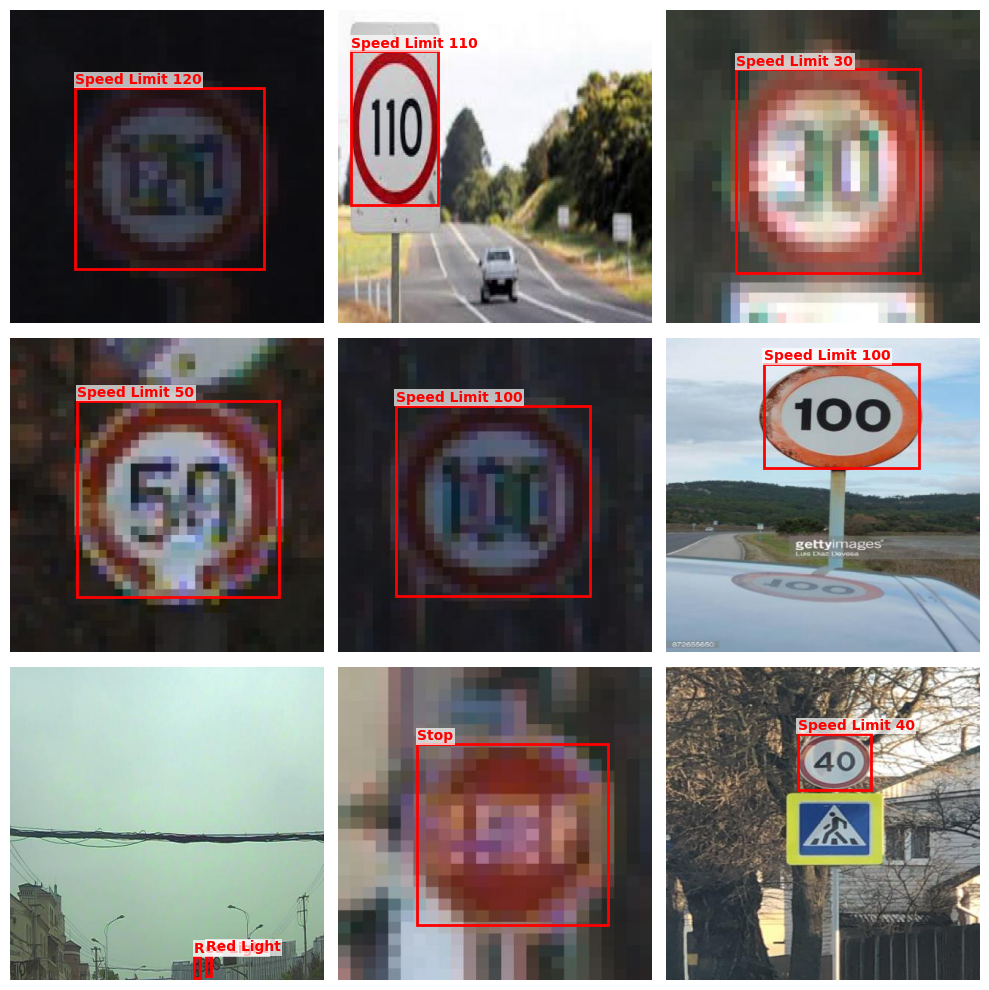

In [16]:
valid_img_paths = glob.glob("cardetection_dataset/car/valid/images/*.jpg")

if valid_img_paths:
    samples = random.sample(valid_img_paths, min(9, len(valid_img_paths)))
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()

    for i, img_path in enumerate(samples):
        images_with_bboxes(img_path, ax=axes[i], show_shape=True)

    plt.tight_layout()
    plt.show()
else:
    print("No validation images found.")

###**DATA PREPROCESSING**

In [17]:
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [18]:
class TrafficSignDataset(Dataset):
    def __init__(self, img_dir, label_dir, S=7, B=2, C=15, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.S = S
        self.B = B
        self.C = C
        self.images = [
            f for f in os.listdir(img_dir)
            if f.endswith(('.jpg', '.png', '.jpeg'))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_file = self.images[index]
        img_path = os.path.join(self.img_dir, img_file)

        # Determine corresponding label file path
        label_file = img_file.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_file)

        # Parse bounding boxes
        boxes = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    if data:
                        class_label = int(data[0])
                        x = float(data[1])
                        y = float(data[2])
                        width = float(data[3])
                        height = float(data[4])
                        boxes.append([class_label, x, y, width, height])

        # Load image
        image = Image.open(img_path).convert("RGB")

        # Apply transformations.
        # Note: Since YOLO coordinates are normalized, standard resizing
        # preserves spatial accuracy without altering the bounding box values.
        if self.transform:
            image = self.transform(image)

        # Initialize target tensor
        label_matrix = torch.zeros((self.S, self.S, self.C + 5 * self.B))

        for box in boxes:
            class_label, x, y, width, height = box

            # Grid Assignment
            i, j = int(self.S * y), int(self.S * x)

            # Coordinate Conversion
            x_cell, y_cell = self.S * x - j, self.S * y - i
            width_cell, height_cell = width * self.S, height * self.S

            # Tensor Population
            if label_matrix[i, j, self.C] == 0:
                # Set objectness score to 1
                label_matrix[i, j, self.C] = 1

                # Assign relative box coordinates
                box_coordinates = torch.tensor(
                    [x_cell, y_cell, width_cell, height_cell]
                )
                label_matrix[i, j, self.C + 1: self.C + 5] = box_coordinates

                # Apply one-hot encoding for the class
                label_matrix[i, j, class_label] = 1

        return image, label_matrix

In [19]:
# Define execution parameters
GRID_SIZE = 52
BBOXES = 2
CLASSES = 15
BATCH_SIZE = 16
NUM_WORKERS = 2

# Define transformations
transform_pipeline = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.ToTensor(),
])

# Define directory paths
train_img_dir = 'cardetection_dataset/car/train/images'
train_label_dir = 'cardetection_dataset/car/train/labels'
val_img_dir = 'cardetection_dataset/car/valid/images'
val_label_dir = 'cardetection_dataset/car/valid/labels'
test_img_dir = 'cardetection_dataset/car/test/images'
test_label_dir = 'cardetection_dataset/car/test/labels'

# Instantiate datasets
train_dataset = TrafficSignDataset(
    img_dir=train_img_dir,
    label_dir=train_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=transform_pipeline
)

val_dataset = TrafficSignDataset(
    img_dir=val_img_dir,
    label_dir=val_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=transform_pipeline
)

test_dataset = TrafficSignDataset(
    img_dir=test_img_dir,
    label_dir=test_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=transform_pipeline
)

# Initialize DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    drop_last=False
)

###**MODEL BUILDING**

In [20]:
import torch.nn as nn

In [21]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CNNBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.leakyrelu = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.leakyrelu(self.batchnorm(self.conv(x)))

class TrafficSignDetector(nn.Module):
    def __init__(self, in_channels=3):
        super(TrafficSignDetector, self).__init__()
        self.S = 52
        self.B = 2
        self.C = 15

        # Define the convolutional architecture
        self.features = nn.Sequential(
            CNNBlock(in_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(64, 192, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(192, 128, kernel_size=1),
            CNNBlock(128, 256, kernel_size=3, padding=1),
            CNNBlock(256, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),

            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),

            CNNBlock(1024, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, stride=1, padding=1), # Changed stride from 2 to 1

            CNNBlock(1024, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, padding=1)
        )

        # Fully convolutional head to replace linear layers
        self.head = nn.Conv2d(1024, self.C + self.B * 5, kernel_size=1)

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)

        # Reshape to match DataLoader target tensor format
        # Permute from (Batch, Channels, S, S) to (Batch, S, S, Channels)
        x = x.permute(0, 2, 3, 1)
        return x

num_classes = len(class_names)

In [22]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [23]:
model = TrafficSignDetector(in_channels=3)

In [24]:
!pip install torchinfo

In [25]:
# Get model summary
import torchinfo

torchinfo.summary(model=model)

Layer (type:depth-idx)                   Param #
TrafficSignDetector                      --
├─Sequential: 1-1                        --
│    └─CNNBlock: 2-1                     --
│    │    └─Conv2d: 3-1                  9,408
│    │    └─BatchNorm2d: 3-2             128
│    │    └─LeakyReLU: 3-3               --
│    └─MaxPool2d: 2-2                    --
│    └─CNNBlock: 2-3                     --
│    │    └─Conv2d: 3-4                  110,592
│    │    └─BatchNorm2d: 3-5             384
│    │    └─LeakyReLU: 3-6               --
│    └─MaxPool2d: 2-4                    --
│    └─CNNBlock: 2-5                     --
│    │    └─Conv2d: 3-7                  24,576
│    │    └─BatchNorm2d: 3-8             256
│    │    └─LeakyReLU: 3-9               --
│    └─CNNBlock: 2-6                     --
│    │    └─Conv2d: 3-10                 294,912
│    │    └─BatchNorm2d: 3-11            512
│    │    └─LeakyReLU: 3-12              --
│    └─CNNBlock: 2-7                     --
│    │

###**MODEL TRAINING**

In [26]:
import torch.optim as optim
from torchvision.ops import box_iou, box_convert

In [27]:
class CustomLoss(nn.Module):
    def __init__(self, S=52, B=2, C=15):
        super(CustomLoss, self).__init__()
        self.mse = nn.MSELoss(reduction="sum")
        self.S = S
        self.B = B
        self.C = C
        self.lambda_noobj = 0.5
        self.lambda_coord = 5

    def forward(self, predictions, target):
        predictions = predictions.reshape(-1, self.S, self.S, self.C + self.B * 5)
        target = target.reshape(-1, self.S, self.S, self.C + self.B * 5)

        # Extract bounding boxes for both predictions
        box1_preds = predictions[..., self.C+1 : self.C+5]
        box2_preds = predictions[..., self.C+6 : self.C+10]

        target_boxes = target[..., self.C+1 : self.C+5]

        box1_preds_xyxy = box_convert(box1_preds.reshape(-1, 4), in_fmt='cxcywh', out_fmt='xyxy')
        box2_preds_xyxy = box_convert(box2_preds.reshape(-1, 4), in_fmt='cxcywh', out_fmt='xyxy')
        target_boxes_xyxy = box_convert(target_boxes.reshape(-1, 4), in_fmt='cxcywh', out_fmt='xyxy')

        iou_b1 = box_iou(box1_preds_xyxy, target_boxes_xyxy).diag().reshape(-1, self.S, self.S, 1)
        iou_b2 = box_iou(box2_preds_xyxy, target_boxes_xyxy).diag().reshape(-1, self.S, self.S, 1)

        ious = torch.cat([iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)], dim=0)
        iou_maxes, bestbox = torch.max(ious, dim=0)

        exists_box = target[..., self.C].unsqueeze(3)

        # For box coordinates
        box_predictions = exists_box * (
            (
                bestbox * predictions[..., self.C+6 : self.C+10]
                + (1 - bestbox) * predictions[..., self.C+1 : self.C+5]
            )
        )
        box_targets = exists_box * target_boxes

        # We add 1e-6 to prevent gradient explosion at derivative of sqrt(0)
        box_predictions[..., 2:4] = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(
            torch.abs(box_predictions[..., 2:4] + 1e-6)
        )
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])

        box_loss = self.mse(
            torch.flatten(box_predictions, end_dim=-2),
            torch.flatten(box_targets, end_dim=-2)
        )

        # Object detected loss
        pred_box = (
            bestbox * predictions[..., self.C+5 : self.C+6]
            + (1 - bestbox) * predictions[..., self.C : self.C+1]
        )
        object_loss = self.mse(
            torch.flatten(exists_box * pred_box),
            torch.flatten(exists_box * target[..., self.C : self.C+1])
        )

        # No object detected loss
        no_object_loss = self.mse(
            torch.flatten((1 - exists_box) * predictions[..., self.C : self.C+1], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., self.C : self.C+1], start_dim=1)
        )
        no_object_loss += self.mse(
            torch.flatten((1 - exists_box) * predictions[..., self.C+5 : self.C+6], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., self.C : self.C+1], start_dim=1)
        )

        # Classification loss
        class_loss = self.mse(
            torch.flatten(exists_box * predictions[..., :self.C], end_dim=-2),
            torch.flatten(exists_box * target[..., :self.C], end_dim=-2)
        )

        # Total loss
        loss = (
            self.lambda_coord * box_loss
            + object_loss
            + self.lambda_noobj * no_object_loss
            + class_loss
        )

        return loss / predictions.shape[0]

custom_loss_module = CustomLoss(S=52, B=2, C=15)

def custom_loss(predictions, targets):
    return custom_loss_module(predictions, targets)

optimizer = optim.Adam(params=model.parameters(), lr=0.001)

In [28]:
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) # weight decay for regularization to prevent overfitting
# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

model.to(device)

def train_fn(train_loader, model, optimizer, loss_fn):
    loop = tqdm(train_loader, leave=True)
    mean_loss = []

    for batch_idx, (x, y) in enumerate(loop):
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = loss_fn(out, y)

        mean_loss.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # update progress bar
        loop.set_postfix(loss=loss.item())

    return sum(mean_loss) / len(mean_loss)

def val_fn(val_loader, model, loss_fn):
    loop = tqdm(val_loader, leave=True)
    mean_loss = []

    with torch.inference_mode():
        for batch_idx, (x, y) in enumerate(loop):
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = loss_fn(out, y)

            mean_loss.append(loss.item())
            loop.set_postfix(val_loss=loss.item())

    return sum(mean_loss) / len(mean_loss)

epochs = 100
epoch_count = []
loss_values = []
val_loss_values = []

print(f"Starting training on {device}...")
for epoch in range(epochs):
    print(f"\nEpoch: {epoch+1}/{epochs}")

    # Training Phase
    model.train()
    avg_loss = train_fn(train_loader, model, optimizer, custom_loss)

    # Validation Phase
    model.eval()
    avg_val_loss = val_fn(val_loader, model, custom_loss)

    # Step the scheduler based on the validation loss
    scheduler.step(avg_val_loss)

    epoch_count.append(epoch + 1)
    loss_values.append(avg_loss)
    val_loss_values.append(avg_val_loss)

    print(f"Epoch {epoch+1} Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Starting training on cpu...

Epoch: 1/100


  0%|          | 0/220 [00:00<?, ?it/s]

###**MODEL TESTING**

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
# Gather predicted and actual values
def get_predictions(model, dataloader, device, conf_threshold=0.2):
    model.eval()
    all_preds = []
    all_targets = []

    S = 52
    B = 2
    C = 15

    with torch.inference_mode():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            batch_size = logits.shape[0]

            # Reshape predictions and targets
            predictions = logits.reshape(-1, S, S, C + B * 5)
            targets = targets.reshape(-1, S, S, C + B * 5)

            for b in range(batch_size):
                pred = predictions[b]

                # Get classes, confidences, and boxes
                pred_classes = torch.argmax(pred[..., :C], dim=-1)

                # Extract boxes and confidences
                conf1 = pred[..., C:C+1]
                box1 = pred[..., C+1:C+5]
                conf2 = pred[..., C+5:C+6]
                box2 = pred[..., C+6:C+10]

                # Choose the box with the highest confidence for each grid cell
                conf_mask = conf1 > conf2
                best_conf = torch.where(conf_mask, conf1, conf2).squeeze(-1)
                best_box = torch.where(conf_mask.expand_as(box1), box1, box2)

                # Filter by confidence threshold
                mask = best_conf > conf_threshold

                filtered_boxes = best_box[mask]
                filtered_scores = best_conf[mask]
                filtered_classes = pred_classes[mask]

                if filtered_boxes.shape[0] > 0:
                    pred_boxes_xyxy = box_convert(filtered_boxes, in_fmt='cxcywh', out_fmt='xyxy')
                else:
                    pred_boxes_xyxy = torch.empty((0, 4), device=device)

                all_preds.append({
                    'boxes': pred_boxes_xyxy,
                    'scores': filtered_scores,
                    'labels': filtered_classes
                })

                target = targets[b]

                target_conf = target[..., C]
                target_classes = torch.argmax(target[..., :C], dim=-1)
                target_boxes = target[..., C+1:C+5]

                obj_mask = target_conf == 1

                t_boxes = target_boxes[obj_mask]
                t_labels = target_classes[obj_mask]

                if t_boxes.shape[0] > 0:
                    target_boxes_xyxy = box_convert(t_boxes, in_fmt='cxcywh', out_fmt='xyxy')
                else:
                    target_boxes_xyxy = torch.empty((0, 4), device=device)

                all_targets.append({
                    'boxes': target_boxes_xyxy,
                    'labels': t_labels
                })

    return all_preds, all_targets

In [ ]:
train_labels, train_preds = get_predictions(model, train_loader, device)
test_labels, test_preds = get_predictions(model, test_loader, device)

###**MODEL EVALUATION**

In [ ]:
!pip install -q torchmetrics

In [ ]:
from sklearn.metrics import f1_score
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [ ]:
def evaluate_model(model, dataloader, device):
    print("Evaluating model...")
    map_metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')

    # Get predictions and targets in the format expected by torchmetrics
    preds, targets = get_predictions(model, dataloader, device)

    map_metric.update(preds, targets)
    map_results = map_metric.compute()

    print(f"mAP (IoU=0.50:0.95): {map_results['map']:.4f}")
    print(f"mAP (IoU=0.50): {map_results['map_50']:.4f}")
    print(f"mAP (IoU=0.75): {map_results['map_75']:.4f}")

    return map_results['map']

test_map = evaluate_model(model, test_loader, device)

###**VISUALIZATION OF RESULTS**

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epoch_count, loss_values, label="Train loss", color="blue", marker="o")
plt.plot(epoch_count, val_loss_values, label="Validation loss", color="orange", marker="x")
plt.title("Training and Validation Loss Curve")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from torchvision.ops import box_iou
import numpy as np

# Get predictions from the test set
preds, targets = get_predictions(model, test_loader, device)

y_true = []
y_pred = []
num_classes = 15
background_class = num_classes  # Use class ID 15 for Background

# Match predictions to ground truth targets to build the confusion matrix lists
for i in range(len(targets)):
    t_boxes = targets[i]['boxes']
    t_labels = targets[i]['labels']
    p_boxes = preds[i]['boxes']
    p_labels = preds[i]['labels']

    if len(t_boxes) == 0 and len(p_boxes) == 0:
        continue
    elif len(t_boxes) == 0:
        # All predictions are False Positives (Background truth)
        y_pred.extend(p_labels.cpu().numpy())
        y_true.extend([background_class] * len(p_boxes))
        continue
    elif len(p_boxes) == 0:
        # All targets are False Negatives (Background predicted)
        y_true.extend(t_labels.cpu().numpy())
        y_pred.extend([background_class] * len(t_boxes))
        continue

    # Compute IoU between target and predicted boxes
    ious = box_iou(t_boxes, p_boxes)  # Shape: (N_t, N_p)

    matched_preds = set()
    for t_idx, t_label in enumerate(t_labels):
        best_iou, p_idx = ious[t_idx].max(dim=0)
        if best_iou > 0.5:
            # True Positive or Misclassification
            y_true.append(t_label.item())
            y_pred.append(p_labels[p_idx].item())
            matched_preds.add(p_idx.item())
        else:
            # False Negative (Missed object)
            y_true.append(t_label.item())
            y_pred.append(background_class)

    # Any predictions not matched to a target are False Positives
    for p_idx, p_label in enumerate(p_labels):
        if p_idx not in matched_preds:
            y_pred.append(p_label.item())
            y_true.append(background_class)

# Extend class names with the Background class
ext_class_names = class_names + ["Background"]

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(num_classes + 1))

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ext_class_names, yticklabels=ext_class_names)
plt.title('Confusion Matrix (IoU > 0.5)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##**Ultralytics Modeling**

In [ ]:
!pip install ultralytics

import os
import glob
from IPython.display import Image, display
from ultralytics import YOLO

In [ ]:
# Initialize the YOLOv8 Nano architecture
model_ultralytics = YOLO('yolov8n.pt')

# Define the absolute or relative path to the dataset configuration file
yaml_path = 'cardetection_dataset/car/data.yaml'

# Execute the training sequence
results = model_ultralytics.train(
    data=yaml_path,
    epochs=20,
    imgsz=416,
    batch=16,
    device=0, # Designates GPU execution
    project='yolov8_traffic_signs',
    name='train_run'
)

In [ ]:
# Execute validation on the test subset
metrics = model_ultralytics.val(
    split='test',
    project='yolov8_traffic_signs',
    name='val_run'
)

# Output exact Mean Average Precision metrics
print("Quantitative Metrics (Test Set):")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP75:    {metrics.box.map75:.4f}")

In [ ]:
import os
from IPython.display import Image, display

# Corrected paths pointing to the nested Ultralytics directories
train_dir = '/content/runs/detect/yolov8_traffic_signs/train_run'
val_dir = '/content/runs/detect/yolov8_traffic_signs/val_run'

results_img_path = f'{train_dir}/results.png'
confusion_matrix_path = f'{val_dir}/confusion_matrix_normalized.png'
pr_curve_path = f'{val_dir}/PR_curve.png'

print("Model Training Curves (Loss & mAP):")
if os.path.exists(results_img_path):
    display(Image(filename=results_img_path, width=1000))
else:
    print(f"File not found at: {results_img_path}")

print("\nPrecision-Recall Curve:")
if os.path.exists(pr_curve_path):
    display(Image(filename=pr_curve_path, width=800))
else:
    print(f"File not found at: {pr_curve_path}")

print("\nNormalized Confusion Matrix:")
if os.path.exists(confusion_matrix_path):
    display(Image(filename=confusion_matrix_path, width=800))
else:
    print(f"File not found at: {confusion_matrix_path}")

In [ ]:
# Retrieve sample images from the test directory
test_dir = 'cardetection_dataset/car/test/images/*.jpg'
sample_images = glob.glob(test_dir)[:5]

# Execute inference and save spatial predictions
predict_results = model_ultralytics.predict(
    source=sample_images,
    conf=0.25,
    save=True,
    project='yolov8_traffic_signs',
    name='predict_run'
)

# Display the annotated output images
# Use the save_dir from the first result to get the correct output folder
predicted_images_dir = predict_results[0].save_dir
predicted_images = glob.glob(f'{predicted_images_dir}/*.jpg')

print("Visual Inference Samples:")
for img_path in predicted_images:
    display(Image(filename=img_path, width=600))